<a href="https://colab.research.google.com/github/Ariqq16/ML_2026/blob/main/JS05/JS05_Tugas_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/sample_data/voice.csv")

print("Ukuran dataset:", df.shape)

print(df.head())

print("\nJumlah data setiap kelas:")
print(df["label"].value_counts())

Ukuran dataset: (3168, 21)
   meanfreq        sd    median       Q25       Q75       IQR       skew  \
0  0.059781  0.064241  0.032027  0.015071  0.090193  0.075122  12.863462   
1  0.066009  0.067310  0.040229  0.019414  0.092666  0.073252  22.423285   
2  0.077316  0.083829  0.036718  0.008701  0.131908  0.123207  30.757155   
3  0.151228  0.072111  0.158011  0.096582  0.207955  0.111374   1.232831   
4  0.135120  0.079146  0.124656  0.078720  0.206045  0.127325   1.101174   

          kurt    sp.ent       sfm  ...  centroid   meanfun    minfun  \
0   274.402906  0.893369  0.491918  ...  0.059781  0.084279  0.015702   
1   634.613855  0.892193  0.513724  ...  0.066009  0.107937  0.015826   
2  1024.927705  0.846389  0.478905  ...  0.077316  0.098706  0.015656   
3     4.177296  0.963322  0.727232  ...  0.151228  0.088965  0.017798   
4     4.333713  0.971955  0.783568  ...  0.135120  0.106398  0.016931   

     maxfun   meandom    mindom    maxdom   dfrange   modindx  label  
0  0.2

In [2]:
X = df.drop("label", axis=1)
y = df["label"]

print("Fitur:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Fitur:
['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']

Target:
label


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi KNN:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi KNN: 0.9763406940063092

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



In [4]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    "Fitur": X.columns,
    "F-Score": f_scores,
    "P-Value": p_values
})

feature_scores = feature_scores.sort_values(
    by="F-Score",
    ascending=False
)

print(feature_scores)

       Fitur      F-Score        P-Value
12   meanfun  7228.790362   0.000000e+00
5        IQR  1965.750000   0.000000e+00
3        Q25  1121.569224  9.140832e-211
8     sp.ent  1003.308717  1.614016e-191
1         sd   945.461376  6.654756e-182
9        sfm   463.923194   3.877715e-96
11  centroid   406.752820   3.368951e-85
0   meanfreq   406.752820   3.368951e-85
2     median   277.588158   8.259210e-60
17    maxdom   126.024161   1.050986e-28
16    mindom   125.110999   1.636130e-28
18   dfrange   121.457858   9.626061e-28
15   meandom   119.959108   1.992966e-27
10      mode    96.257909   2.097044e-22
14    maxfun    90.228036   4.044625e-21
13    minfun    60.282137   1.101400e-14
7       kurt    24.255365   8.869557e-07
4        Q75    14.236082   1.642021e-04
6       skew     4.252980   3.926293e-02
19   modindx     3.006445   8.303136e-02


In [5]:
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

feature_results = []

for jumlah_fitur in range(1, 21):

    model = Pipeline([
        ("select", SelectKBest(
            score_func=f_classif,
            k=jumlah_fitur
        )),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=8))
    ])

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    feature_results.append({
        "Jumlah Fitur": jumlah_fitur,
        "Accuracy": score
    })

feature_results = pd.DataFrame(feature_results)

print(feature_results)

    Jumlah Fitur  Accuracy
0              1  0.945704
1              2  0.967802
2              3  0.971590
3              4  0.972854
4              5  0.977901
5              6  0.982007
6              7  0.981693
7              8  0.979481
8              9  0.982641
9             10  0.978219
10            11  0.977272
11            12  0.976642
12            13  0.976010
13            14  0.976326
14            15  0.974116
15            16  0.975065
16            17  0.975065
17            18  0.974116
18            19  0.974115
19            20  0.972855


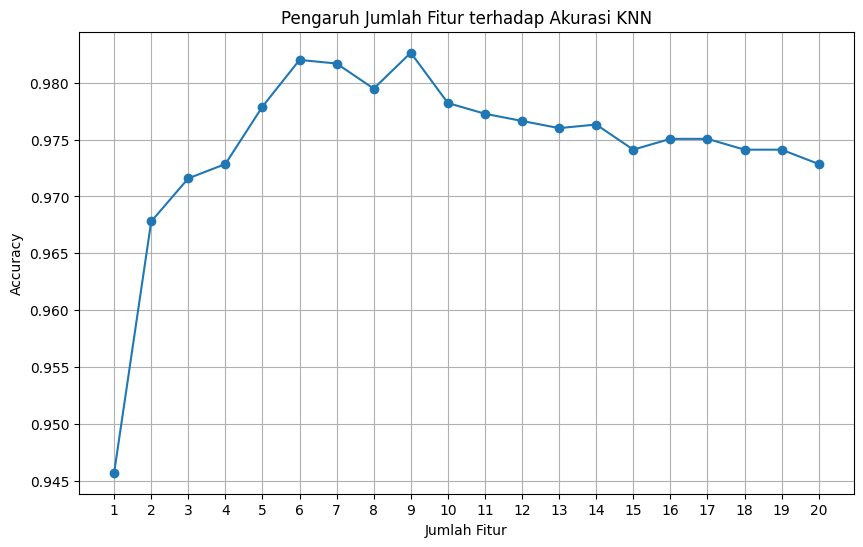

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    feature_results["Jumlah Fitur"],
    feature_results["Accuracy"],
    marker="o"
)

plt.xlabel("Jumlah Fitur")
plt.ylabel("Accuracy")
plt.title("Pengaruh Jumlah Fitur terhadap Akurasi KNN")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

In [7]:
selected_features = [
    "meanfun",
    "IQR",
    "Q25",
    "sp.ent",
    "sd",
    "sfm",
    "centroid",
    "meanfreq",
    "median"
]

X_selected = X[selected_features]

k_results = []

for k in range(1, 31):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    score = cross_val_score(
        model,
        X_selected,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    k_results.append({
        "k": k,
        "Accuracy": score
    })

k_results = pd.DataFrame(k_results)

print(k_results)

     k  Accuracy
0    1  0.977272
1    2  0.979796
2    3  0.979166
3    4  0.982007
4    5  0.982324
5    6  0.981377
6    7  0.981062
7    8  0.982641
8    9  0.978852
9   10  0.979168
10  11  0.978852
11  12  0.978536
12  13  0.978536
13  14  0.976959
14  15  0.975380
15  16  0.974749
16  17  0.973171
17  18  0.973803
18  19  0.972540
19  20  0.973172
20  21  0.972540
21  22  0.972540
22  23  0.972225
23  24  0.972856
24  25  0.971908
25  26  0.971908
26  27  0.970961
27  28  0.970961
28  29  0.970330
29  30  0.969383


In [8]:
best_k = k_results.loc[
    k_results["Accuracy"].idxmax()
]

print("k terbaik:", best_k["k"])
print("Accuracy terbaik:", best_k["Accuracy"])

k terbaik: 8.0
Accuracy terbaik: 0.98264087191831


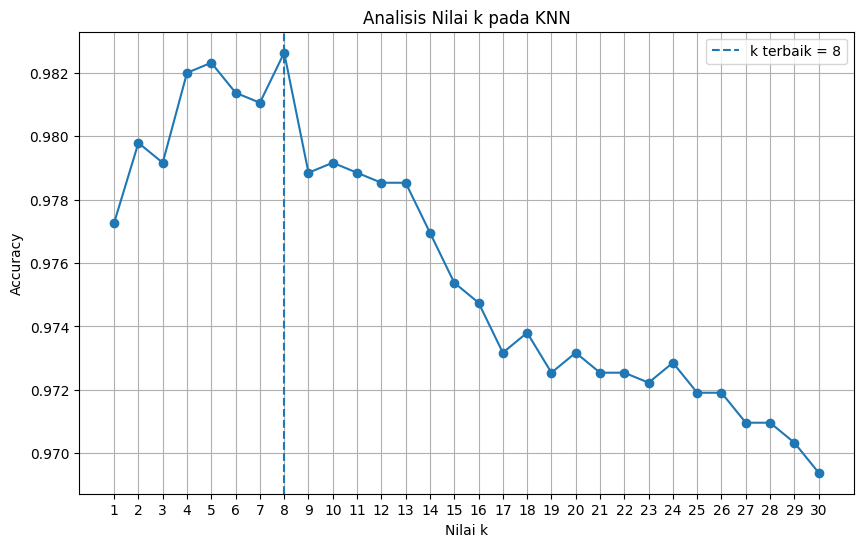

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_results["k"],
    k_results["Accuracy"],
    marker="o"
)

plt.axvline(
    x=8,
    linestyle="--",
    label="k terbaik = 8"
)

plt.xlabel("Nilai k")
plt.ylabel("Accuracy")
plt.title("Analisis Nilai k pada KNN")
plt.xticks(range(1, 31))
plt.grid(True)
plt.legend()

plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=8))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=== HASIL MODEL FINAL ===")
print("Jumlah fitur :", len(selected_features))
print("Fitur        :", selected_features)
print("Nilai k      : 8")
print("Accuracy     :", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== HASIL MODEL FINAL ===
Jumlah fitur : 9
Fitur        : ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median']
Nilai k      : 8
Accuracy     : 0.9826498422712934

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.98      0.98       317
        male       0.98      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

